# 12. 최종 모델 비교 (model_comparison)

각자 폴더에 저장된 최적 모델(joblib)을 **직접 로드해서** 같은 Val 데이터로 재평가하고 비교한다.

기존 12번 노트북과 다른 점: 결과를 하드코딩하지 않는다. 전처리나 모델이 바뀌어 joblib이 갱신되면, 이 노트북을 재실행하는 것만으로 비교표가 자동으로 갱신된다.

**평가 원칙**
- Val 데이터로만 비교한다 (Test는 최종 모델 1회만)
- **AUC**로 모델의 판별력을 비교하고(임계값 무관), 운영 성능은 **모델별 최적 임계값**에서 비교한다
- 임계값 선택 규칙은 전 모델 공통: Recall ≥ 0.80 만족하는 임계값 중 F1 최대 지점
- 여기서 확정한 임계값은 Test 평가 시 그대로 사용한다 (Test 보고 재조정 금지)
- 이탈(1) Recall 우선

## 0. 설정

프로젝트 루트는 `data/preprocessed`가 있는 폴더를 상위로 올라가며 자동 탐색한다 — 노트북이 어느 폴더에 있어도 동작.

`MODEL_PATHS`에 각자 모델 경로를 수동 등록하거나, `AUTO_GLOB_PATTERNS`로 자동 수집한다.

In [1]:
from pathlib import Path

def find_root(start: Path = Path.cwd()) -> Path:
    """현재 위치에서 상위로 올라가며 data/preprocessed가 있는 폴더를 프로젝트 루트로 인식"""
    for p in [start, *start.parents]:
        if (p / "data" / "preprocessed").exists():
            return p
    raise FileNotFoundError("상위 경로에서 data/preprocessed를 찾지 못함")

ROOT = find_root()
DATA_DIR = ROOT / "data" / "preprocessed"
print(f"ROOT: {ROOT}")

# 방법 1) 수동 등록 — "표시이름": "joblib 경로"
MODEL_PATHS = {
    # "RF (mm)": ROOT / "members" / "mm" / "model_final.joblib",
    # "XGB (jhd)": ROOT / "members" / "jhd" / "model_final.joblib",
}

# 방법 2) 자동 탐색 — 아래 패턴에 걸리는 joblib 전부 수집
AUTO_GLOB_PATTERNS = [
    "members/*/*.joblib",
    "models/**/*.joblib",
]

# 임계값 공통 선택 규칙: Recall >= RECALL_FLOOR 중 F1 최대
RECALL_FLOOR = 0.80
THR_SCAN = (0.20, 0.71, 0.01)  # 스캔 범위 (start, stop, step)

ROOT: D:\SKN_AI\Project2


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix,
)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 1. 데이터 로드 (Val)

In [9]:
def load_split(name: str):
    """data/preprocessed/에서 csv 우선, 없으면 joblib/parquet 순으로 로드"""
    for ext, loader in [
        (".csv", lambda p: pd.read_csv(p)),
        (".joblib", joblib.load),
        (".parquet", pd.read_parquet),
    ]:
        p = DATA_DIR / f"{name}{ext}"
        if p.exists():
            return loader(p)
    raise FileNotFoundError(f"{DATA_DIR}/{name}.* 없음")

X_val = load_split("X_val")
y_val = load_split("y_val")
if isinstance(y_val, pd.DataFrame):
    y_val = y_val.iloc[:, 0]
y_val = np.asarray(y_val).ravel()

print(f"X_val: {X_val.shape}, 이탈률: {y_val.mean():.3f}")
X_val.head(2)

X_val: (864, 10), 이탈률: 0.494


,net_revenue,recency_days,frequency,distinct_products,tenure_days,avg_days_between_orders,is_low_value,is_uk,has_return,recent_activity_ratio
0,-0.6501,-1.2112,-0.3393,-0.5886,-1.9239,-1.0996,1.0000,1.0000,0.0000,1.0000
1,-1.6166,-0.6049,-0.4752,-0.5609,-1.7831,-0.4601,1.0000,1.0000,0.0000,1.0000


## 2. 모델 수집 및 로드

수동 등록 + 자동 탐색 결과를 합친다. 같은 파일이 두 번 잡히면 한 번만 로드한다.

In [10]:
found = dict(MODEL_PATHS)

for pattern in AUTO_GLOB_PATTERNS:
    for p in sorted(ROOT.glob(pattern)):
        if p.resolve() in {Path(v).resolve() for v in found.values()}:
            continue
        # 표시이름: 상위폴더/파일명 (예: mm/model_final)
        name = f"{p.parent.name}/{p.stem}"
        found[name] = p

models = {}
for name, path in found.items():
    try:
        obj = joblib.load(path)
        if not hasattr(obj, "predict_proba"):
            print(f"[SKIP] {name}: 모델 아님 ({type(obj).__name__})")
            continue
        models[name] = obj
        print(f"[OK] {name}  <- {Path(path).relative_to(ROOT)}")
    except Exception as e:
        print(f"[FAIL] {name}: {e}")

assert models, "로드된 모델이 없음 — MODEL_PATHS 또는 AUTO_GLOB_PATTERNS 확인"
print(f"\n총 {len(models)}개 모델 로드")

[SKIP] final/preprocessor_prototype: 모델 아님 (ColumnTransformer)
[OK] final/rf_prototype  <- models\final\rf_prototype.joblib
[OK] kmk/model_final  <- models\kmk\model_final.joblib

총 2개 모델 로드


## 3. 피처 정렬 안전장치

모델마다 학습 당시 피처 순서·구성이 다를 수 있다(10개 vs 13개 등). `feature_names_in_`이 있으면 그 순서대로 X_val을 재정렬해서 넣는다. 학습에 쓴 피처가 X_val에 없으면 그 모델은 평가에서 제외하고 사유를 출력한다.

In [11]:
def align_features(model, X: pd.DataFrame):
    """모델의 학습 피처 순서에 맞게 컬럼 재정렬. 불가하면 None 반환"""
    feats = getattr(model, "feature_names_in_", None)
    if feats is None:
        return X  # 피처명 정보 없음 — 순서 책임은 저장한 사람에게
    missing = set(feats) - set(X.columns)
    if missing:
        print(f"  누락 피처: {missing}")
        return None
    return X[list(feats)]

## 4. 평가 — 모델별 최적 임계값 방식

모델마다 확률 분포(캘리브레이션)가 달라서 고정 임계값 비교는 불공정하다.
대신 **선택 규칙만 공통**으로 두고(Recall ≥ 0.80 중 F1 최대), 각 모델의 proba로 임계값을 각자 찾는다.

- `AUC` — 임계값 무관 판별력 → **모델 선정 기준**
- `best_thr` — 그 모델의 최적 임계값 (모델마다 다름)
- `@best` 열 — 각자의 최적 지점에서의 운영 성능
- `@0.5` 열 — 참고용

In [12]:
def find_best_threshold(y, proba, recall_floor=RECALL_FLOOR):
    """공통 규칙: Recall >= recall_floor 만족하는 임계값 중 F1 최대 지점 선택"""
    best_t, best_f1 = None, -1
    for t in np.arange(*THR_SCAN):
        pred = (proba >= t).astype(int)
        if recall_score(y, pred) >= recall_floor:
            f1 = f1_score(y, pred)
            if f1 > best_f1:
                best_t, best_f1 = t, f1
    return best_t  # 조건 만족 지점 없으면 None

def evaluate(name, model, X, y):
    Xa = align_features(model, X)
    if Xa is None:
        print(f"[SKIP] {name}: 피처 불일치")
        return None
    proba = model.predict_proba(Xa)[:, 1]
    row = {"model": name, "AUC": roc_auc_score(y, proba)}

    # 참고용: 고정 0.5
    pred = (proba >= 0.5).astype(int)
    row["Recall@0.5"] = recall_score(y, pred)
    row["Precision@0.5"] = precision_score(y, pred)

    # 공정 비교: 모델별 최적 임계값 (공통 규칙)
    t = find_best_threshold(y, proba)
    if t is not None:
        pred = (proba >= t).astype(int)
        row["best_thr"] = t
        row["Recall@best"] = recall_score(y, pred)
        row["Precision@best"] = precision_score(y, pred)
        row["F1@best"] = f1_score(y, pred)
    else:
        row["best_thr"] = np.nan  # Recall 0.80 도달 불가한 모델
    return row, proba

results, probas = [], {}
for name, model in models.items():
    out = evaluate(name, model, X_val, y_val)
    if out:
        row, proba = out
        results.append(row)
        probas[name] = proba

comparison = pd.DataFrame(results).set_index("model").sort_values("AUC", ascending=False)
comparison

,AUC,Recall@0.5,Precision@0.5,best_thr,Recall@best,Precision@best,F1@best
model,,,,,,,
final/rf_prototype,0.7672,0.7424,0.6803,0.3500,0.8923,0.6256,0.7355
kmk/model_final,0.7672,0.7424,0.6803,0.3500,0.8923,0.6256,0.7355


## 5. 비교표 하이라이트

In [13]:
metric_cols = [c for c in comparison.columns if c != "best_thr"]
styled = comparison.style.highlight_max(subset=metric_cols, axis=0, color="#c6efce")
styled

,AUC,Recall@0.5,Precision@0.5,best_thr,Recall@best,Precision@best,F1@best
model,,,,,,,
final/rf_prototype,0.767207,0.742389,0.680258,0.350000,0.892272,0.625616,0.735521
kmk/model_final,0.767207,0.742389,0.680258,0.350000,0.892272,0.625616,0.735521


## 6. ROC / PR 곡선

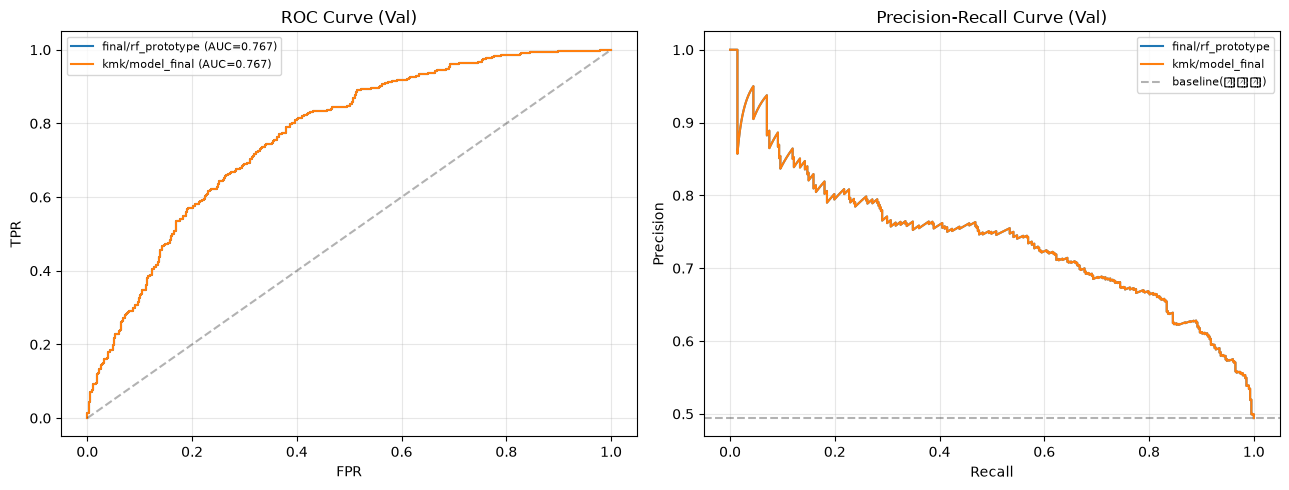

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_val, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_val, proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_val, proba)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(title="ROC Curve (Val)", xlabel="FPR", ylabel="TPR")
axes[1].axhline(y_val.mean(), color="k", ls="--", alpha=0.3, label="baseline(이탈률)")
axes[1].set(title="Precision-Recall Curve (Val)", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 임계값 스캔

모델별로 임계값을 스캔하면서 Recall/Precision 변화를 본다. 빨간 점선이 그 모델의 best_thr — 모델마다 위치가 다른 것이 정상이며, 이것이 고정 임계값 비교가 불공정한 이유의 시각적 근거.

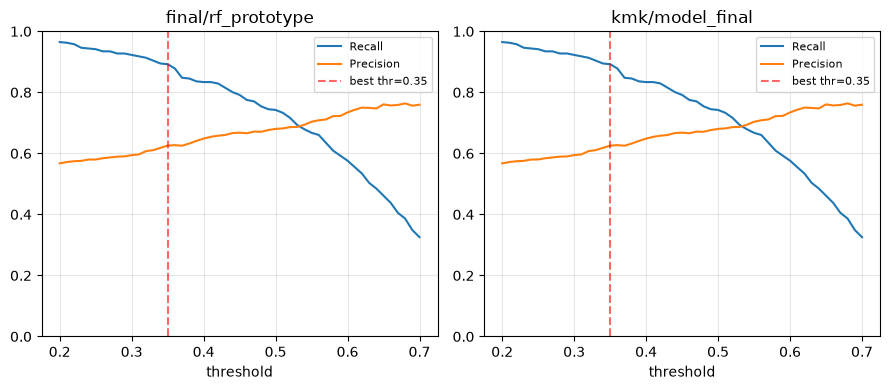

In [15]:
thresholds = np.arange(*THR_SCAN)

fig, axes = plt.subplots(1, len(probas), figsize=(4.5 * len(probas), 4), squeeze=False)
for ax, (name, proba) in zip(axes[0], probas.items()):
    recs = [recall_score(y_val, (proba >= t).astype(int)) for t in thresholds]
    precs = [precision_score(y_val, (proba >= t).astype(int), zero_division=0) for t in thresholds]
    ax.plot(thresholds, recs, "-", label="Recall")
    ax.plot(thresholds, precs, "-", label="Precision")
    t = comparison.loc[name, "best_thr"]
    if not np.isnan(t):
        ax.axvline(t, color="r", ls="--", alpha=0.6, label=f"best thr={t:.2f}")
    ax.set(title=name, xlabel="threshold", ylim=(0, 1))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 최고 모델 혼동행렬 (해당 모델의 best_thr 기준)

In [16]:
best_name = comparison.index[0]
best_thr = comparison.loc[best_name, "best_thr"]
best_proba = probas[best_name]
pred = (best_proba >= best_thr).astype(int)

cm = confusion_matrix(y_val, pred)
print(f"최고 모델(AUC 기준): {best_name}")
print(f"threshold = {best_thr:.2f}\n")
print(pd.DataFrame(cm,
    index=["실제 유지(0)", "실제 이탈(1)"],
    columns=["예측 유지(0)", "예측 이탈(1)"]))

최고 모델(AUC 기준): final/rf_prototype
threshold = 0.35

          예측 유지(0)  예측 이탈(1)
실제 유지(0)       209       228
실제 이탈(1)        46       381


## 9. 최종 모델 승격

비교 결과 확정된 모델을 `models/final/model_final.joblib`으로 복사하고, 그 모델의 best_thr를 `models/final/threshold.txt`에 함께 기록한다. Streamlit `config.py`의 `DEFAULT_THRESHOLD`도 이 값으로 맞춘다.

> 아래 셀은 팀 합의 후 **수동으로** `PROMOTE = True`로 바꿔 실행

In [17]:
PROMOTE = False
PROMOTE_NAME = best_name  # 또는 직접 지정: "RF (mm)"

if PROMOTE:
    import shutil
    src = Path(found[PROMOTE_NAME])
    dst = ROOT / "models" / "final" / "model_final.joblib"
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

    thr = comparison.loc[PROMOTE_NAME, "best_thr"]
    (dst.parent / "threshold.txt").write_text(f"{thr:.2f}", encoding="utf-8")

    print(f"승격 완료: {src.name} -> {dst.relative_to(ROOT)}")
    print(f"운영 임계값: {thr:.2f} -> models/final/threshold.txt")
    print("* Streamlit config.py DEFAULT_THRESHOLD도 이 값으로 갱신할 것")
else:
    print(f"승격 대기 중 (현재 1순위: {best_name}, best_thr={comparison.loc[best_name, 'best_thr']:.2f})")

승격 대기 중 (현재 1순위: final/rf_prototype, best_thr=0.35)
